#Name: Zumer Rafi
#Student ID:23075913


#Installing Required Libraries

In [126]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn prophet tensorflow xgboost
!pip install pytorch-forecasting

#Importing Libraries

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import itertools
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

#Performing EDA

In [128]:
#Importing dataset
file_path = "oil_prices_2426.csv"

df = pd.read_csv(file_path)

df.head()

,date,price (dollars)
0,21/09/2024,32.10
1,22/09/2024,32.25
2,23/09/2024,31.07
3,24/09/2024,31.50
4,25/09/2024,32.21


In [129]:
# Checking for missing (null) values in each column
print("Missing values in each column:")
print(df.isnull().sum())

# Checking if there are any duplicate rows in the dataset
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
date               0
price (dollars)    0
dtype: int64

Number of duplicate rows:
0


In [130]:
# Converting date
df['date'] = pd.to_datetime(df['date'])

# Sorting because data must be in chronological order for time series
df = df.sort_values('date')

# Setting the index
df.set_index('date', inplace=True)

df.head()

,price (dollars)
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


In [131]:
df = pd.read_csv("oil_prices_2426.csv")

# Cleaning column names
df.columns = df.columns.str.strip().str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)

print(df.columns)

Index(['date', 'price_dollars'], dtype='object')


In [132]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

In [133]:
# Creating first and second order differencing
df['Price_diff1'] = df['price_dollars'].diff()
df['Price_diff2'] = df['Price_diff1'].diff()

# Removing rows with NaN values created by differencing
df = df.dropna()

# Verifying the dataset is clean
print("Missing values in dataset:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values in dataset:
price_dollars    0
Price_diff1      0
Price_diff2      0
dtype: int64

Duplicate rows:
0


**Plotting the Graphs(All the graphs are Color-Blind Friendly)**

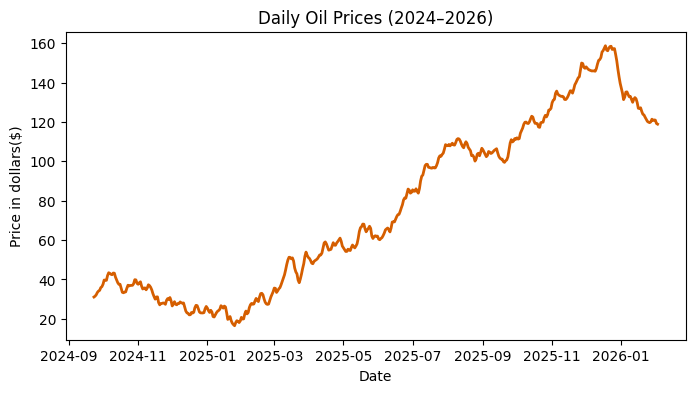

In [134]:
plt.figure(figsize=(8,4))
plt.plot(df['price_dollars'], color='#D55E00', linewidth=2)
plt.title("Daily Oil Prices (2024–2026)")
plt.xlabel("Date")
plt.ylabel("Price in dollars($)")
plt.show()

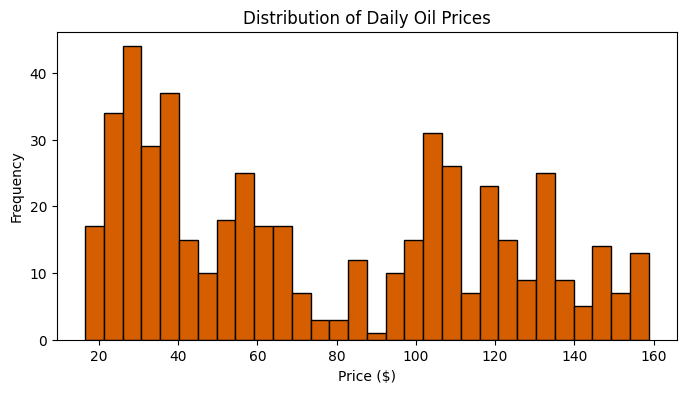

In [135]:
#This is the code to plot Histogram which will help to show how the oil prices are distributed
plt.figure(figsize=(8,4))

plt.hist(df['price_dollars'], bins=30, color='#D55E00', edgecolor='black')

plt.title("Distribution of Daily Oil Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")

plt.show()

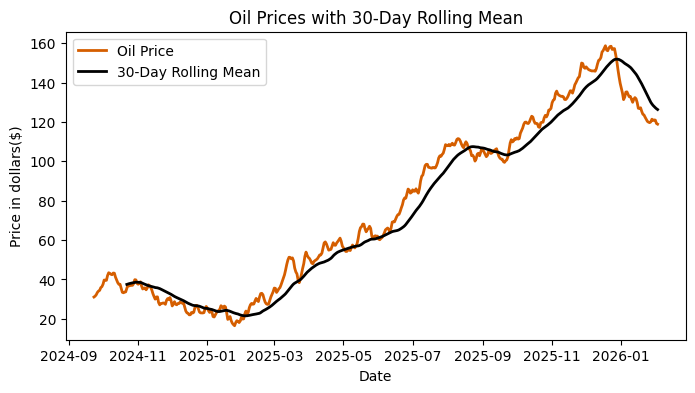

In [136]:
#This is the code to plot Rolling Mean Plot that helps detect trend and non-stationarity
df['rolling_mean'] = df['price_dollars'].rolling(window=30).mean()

plt.figure(figsize=(8,4))

plt.plot(df['price_dollars'], color='#D55E00', linewidth=2, label="Oil Price")
plt.plot(df['rolling_mean'], color='black', linewidth=2, label="30-Day Rolling Mean")

plt.title("Oil Prices with 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price in dollars($)")
plt.legend()

plt.show()

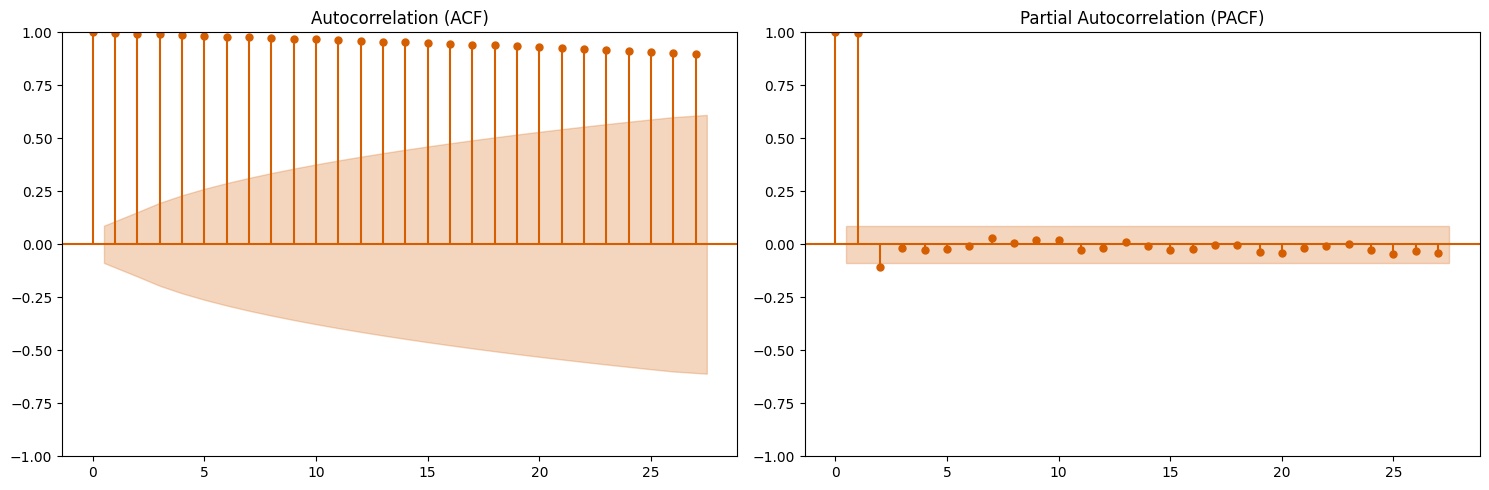

In [137]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

#This is the code for ACF
plot_acf(
    df['price_dollars'],
    ax=ax[0],
    color='#D55E00',
    vlines_kwargs={'color':'#D55E00'},
    alpha=0.05
)

# Changing confidence interval color
ax[0].collections[1].set_color('#D55E00')

ax[0].set_title("Autocorrelation (ACF)")

# This is code for PACF
plot_pacf(
    df['price_dollars'],
    ax=ax[1],
    color='#D55E00',
    vlines_kwargs={'color':'#D55E00'},
    alpha=0.05
)

# Change confidence interval color
ax[1].collections[1].set_color('#D55E00')

ax[1].set_title("Partial Autocorrelation (PACF)")

plt.tight_layout()
plt.show()

#Stationarity Testing

In [138]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(df['price_dollars'])

ADF Statistic: -0.5204232646388982
p-value: 0.8879690385438854


In [139]:
def kpss_test(series):
    result = kpss(series, regression='c')
    print("KPSS Statistic:", result[0])
    print("p-value:", result[1])

kpss_test(df['price_dollars'])

KPSS Statistic: 3.6940922040584243
p-value: 0.01


#Making Data Stationary

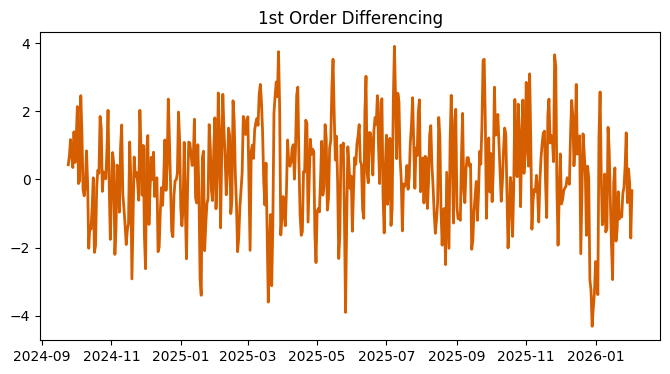

ADF Statistic: -4.545399454619263
p-value: 0.00016265302943645774


In [140]:
df['Price_diff1'] = df['price_dollars'].diff()
df['Price_diff2'] = df['Price_diff1'].diff()

plt.figure(figsize=(8,4))
plt.plot(df['Price_diff1'], color='#D55E00', linewidth=2)
plt.title("1st Order Differencing")
plt.show()

adf_test(df['Price_diff1'].dropna())

#Train-Test Split

In [141]:
train_size = int(len(df) * 0.8)

train = df['price_dollars'].iloc[:train_size]
test = df['price_dollars'].iloc[train_size:]

#GRID SEARCH FOR BEST (p,d,q)

In [142]:
p = range(0,9)
d = range(0,3)
q = range(0,9)

pdq = list(itertools.product(p,d,q))

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        results = model.fit()

        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results

        print(f"ARIMA{order} - AIC:{results.aic}")

    except:
        continue

print("\nBest Model:", best_order)
print("Best AIC:", best_aic)

ARIMA(0, 0, 0) - AIC:3912.3765239789864
ARIMA(0, 0, 1) - AIC:3371.2438576534814
ARIMA(0, 0, 2) - AIC:2851.904556282171
ARIMA(0, 0, 3) - AIC:2444.043425176572
ARIMA(0, 0, 4) - AIC:2155.796318833017
ARIMA(0, 0, 5) - AIC:2466.715048242027
ARIMA(0, 0, 6) - AIC:1820.3698313344212
ARIMA(0, 0, 7) - AIC:1985.403861340351
ARIMA(0, 0, 8) - AIC:2208.9877031134047
ARIMA(0, 1, 0) - AIC:1382.1788820473735
ARIMA(0, 1, 1) - AIC:1121.6010444928006
ARIMA(0, 1, 2) - AIC:1123.4863518956815
ARIMA(0, 1, 3) - AIC:1125.0807414679664
ARIMA(0, 1, 4) - AIC:1122.2789849581343
ARIMA(0, 1, 5) - AIC:1121.5045712297551
ARIMA(0, 1, 6) - AIC:1123.4438492482022
ARIMA(0, 1, 7) - AIC:1124.3154685336947
ARIMA(0, 1, 8) - AIC:1126.2780545657686
ARIMA(0, 2, 0) - AIC:1383.8669902678328
ARIMA(0, 2, 1) - AIC:1368.0120675469184
ARIMA(0, 2, 2) - AIC:1120.154227665386
ARIMA(0, 2, 3) - AIC:1122.154221642719
ARIMA(0, 2, 4) - AIC:1123.345778904517
ARIMA(0, 2, 5) - AIC:1121.690704670982
ARIMA(0, 2, 6) - AIC:1121.689329566684
ARIMA(0, 2

#Fitting the Best Model

In [143]:
model = ARIMA(train, order=best_order)
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:          price_dollars   No. Observations:                  398
Model:                 ARIMA(3, 1, 3)   Log Likelihood                -552.996
Date:                Wed, 11 Mar 2026   AIC                           1119.991
Time:                        14:44:36   BIC                           1147.879
Sample:                    09-23-2024   HQIC                          1131.039
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2889      0.058     22.366      0.000       1.176       1.402
ar.L2         -0.9418      0.078    -12.119      0.000      -1.094      -0.789
ar.L3          0.0243      0.058      0.421      0.6

#This is step for Residual Diagnostics

**ACF of Residuals**

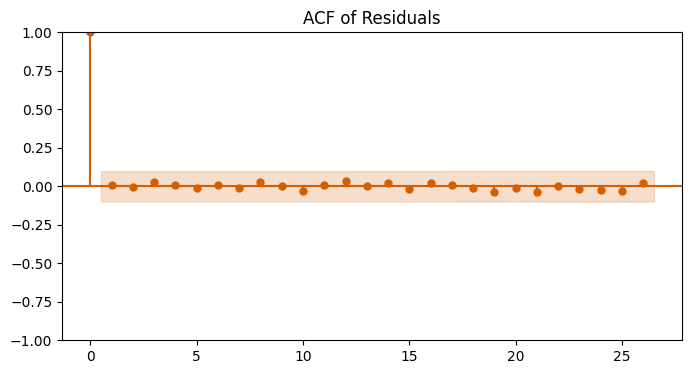

In [144]:
residuals = results.resid

fig, ax = plt.subplots(figsize=(8,4))

plot_acf(
    residuals,
    ax=ax,
    color='#D55E00',
    vlines_kwargs={'colors':'#D55E00'}
)

# Changing confidence interval shading
ax.collections[1].set_color('#D55E00')
ax.collections[1].set_alpha(0.2)

plt.title("ACF of Residuals")

plt.show()

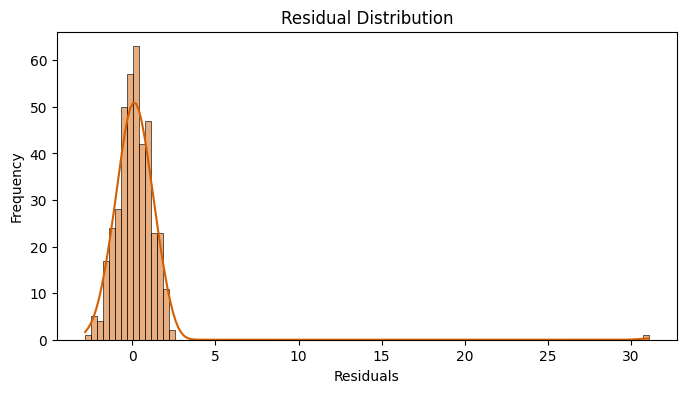

In [145]:
plt.figure(figsize=(8,4))

sns.histplot(residuals, kde=True, color='#D55E00', edgecolor='black')

plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

#Model Performance (RMSE)

In [146]:
forecast_test = results.forecast(steps=len(test))

rmse = sqrt(mean_squared_error(test, forecast_test))
print("RMSE:", rmse)

RMSE: 18.529996176843607


#Forecasting 24 Months Ahead

In [147]:
future_forecast = results.get_forecast(steps=730)  # this is the code for approx 24 months daily

mean_forecast = future_forecast.predicted_mean
conf_int = future_forecast.conf_int()

#Plotting Forecast + Confidence Intervals

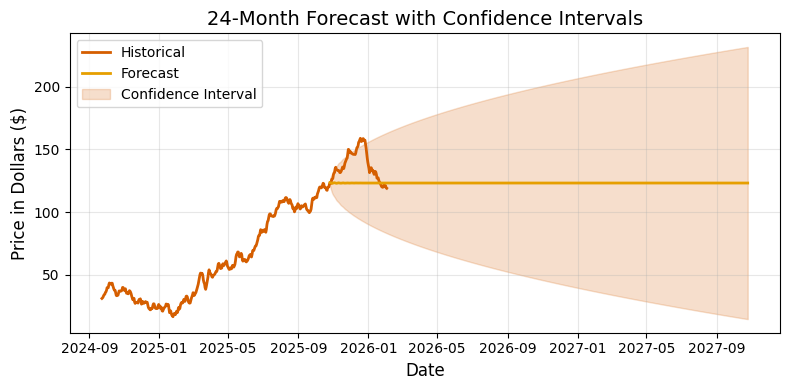

In [148]:
plt.figure(figsize=(8,4))

# Historical data
plt.plot(df.index, df['price_dollars'],
         label='Historical',
         color='#D55E00',
         linewidth=2)

# Forecasting
plt.plot(mean_forecast.index, mean_forecast,
         label='Forecast',
         color='#E69F00',
         linewidth=2)

# This is the code for Confidence interval
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color='#D55E00',
    alpha=0.2,
    label='Confidence Interval'
)

plt.title("24-Month Forecast with Confidence Intervals", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price in Dollars ($)", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Implementing ALTERNATIVE MODELS

**Prophet Model**

In [149]:
# this is the code to prepare data
prophet_df = df.reset_index()
prophet_df = prophet_df[['date','price_dollars']]
prophet_df.columns = ['ds','y']

In [150]:
#Building Model
model_prophet = Prophet()
model_prophet.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [151]:
#Forecasting 24 Months
future = model_prophet.make_future_dataframe(periods=730)
forecast_prophet = model_prophet.predict(future)

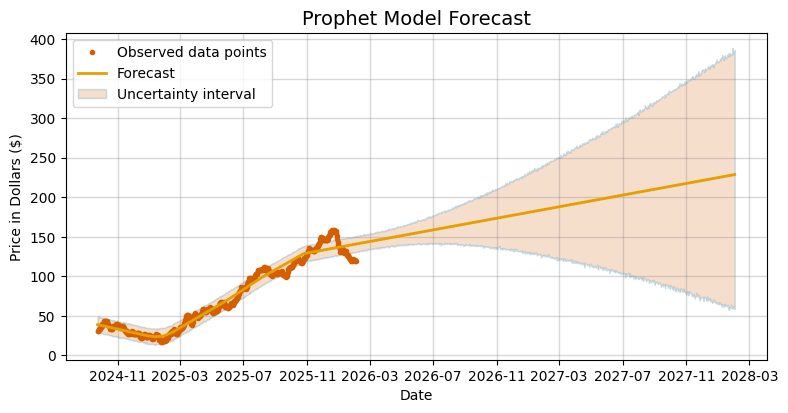

In [152]:
# Plotting Prophet forecast results
fig = model_prophet.plot(forecast_prophet, figsize=(8,4))

# Accessig the axis object to customize colours
ax = fig.gca()

ax.lines[0].set_color('#D55E00')
ax.lines[0].set_linewidth(2)

ax.lines[1].set_color('#E69F00')
ax.lines[1].set_linewidth(2)

for collection in ax.collections:
    collection.set_facecolor('#D55E00')
    collection.set_alpha(0.2)

plt.title("Prophet Model Forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price in Dollars ($)")

plt.grid(alpha=0.3)
plt.legend()


# Displaying the plot
plt.show()

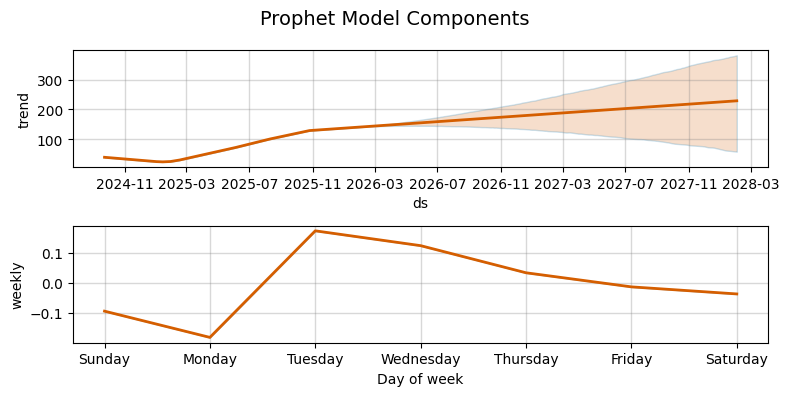

In [153]:
# Plotting Prophet components (trend and seasonality)
fig = model_prophet.plot_components(forecast_prophet, figsize=(8,4))

# Getting all axes from the figure
axes = fig.get_axes()

# Looping through each subplot and change colours
for ax in axes:


    for line in ax.lines:
        line.set_color('#D55E00')
        line.set_linewidth(2)


    for collection in ax.collections:
        collection.set_facecolor('#D55E00')
        collection.set_alpha(0.2)


    ax.grid(alpha=0.3)


plt.suptitle("Prophet Model Components", fontsize=14)

plt.tight_layout()
plt.show()

#Computing RMSE for Prophet

In [154]:
# Extracting Prophet predictions corresponding to the test period
prophet_test = forecast_prophet.set_index('ds').loc[test.index]['yhat']

# Calculating RMSE for Prophet
rmse_prophet = np.sqrt(mean_squared_error(test, prophet_test))

print("Prophet RMSE:", rmse_prophet)

Prophet RMSE: 13.122367976524966


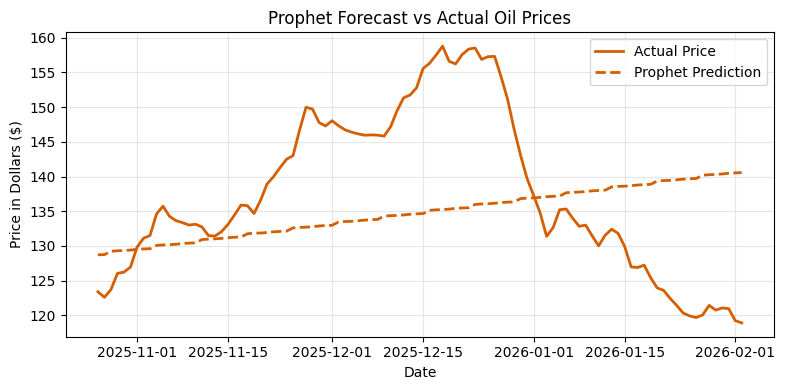

In [155]:
plt.figure(figsize=(8,4))

plt.plot(test.index, test,
         label="Actual Price",
         color='#D55E00',
         linewidth=2)

plt.plot(test.index, prophet_test,
         label="Prophet Prediction",
         color='#D55E00',
         linestyle='--',
         linewidth=2)

plt.title("Prophet Forecast vs Actual Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price in Dollars ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#XGBoost an optional model implementation

In [158]:
df = pd.read_csv("oil_prices_2426.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df = df.rename(columns={'price (dollars)': 'price_dollars'})

In [172]:
future_days = 730

last_values = df['price_dollars'].values[-3:].tolist()

future_predictions = []

for i in range(future_days):

    X_input = np.array(last_values[-3:]).reshape(1,-1)

    pred = model.predict(X_input)[0]

    future_predictions.append(pred)

    last_values.append(pred)

In [161]:
last_date = df['date'].iloc[-1]

future_dates = pd.date_range(
    start=last_date,
    periods=future_days+1,
    freq='D'
)[1:]

In [173]:
future_df = pd.DataFrame({
    'index': future_dates,
    'forecast': future_predictions
})

In [163]:
df['lag1'] = df['price_dollars'].shift(1)
df['lag2'] = df['price_dollars'].shift(2)
df['lag3'] = df['price_dollars'].shift(3)

df = df.dropna()

In [164]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [165]:
features = ['lag1','lag2','lag3']

X_train = train[features]
y_train = train['price_dollars']

X_test = test[features]
y_test = test['price_dollars']

In [166]:
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [167]:
predictions = model.predict(X_test)

In [168]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, predictions))

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 20.688002856955965


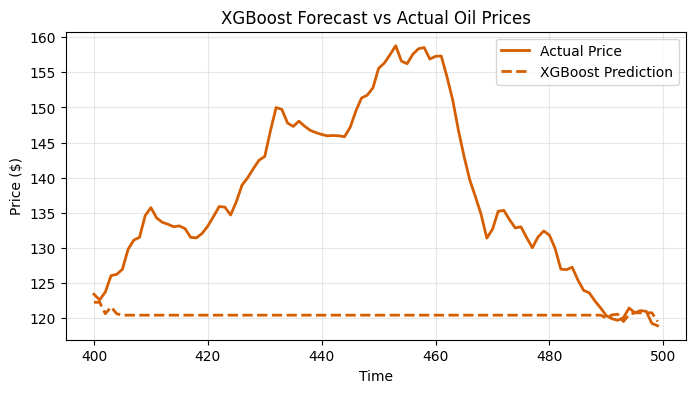

In [169]:
plt.figure(figsize=(8,4))

plt.plot(y_test.index, y_test,
         label="Actual Price",
         color='#D55E00',
         linewidth=2)

plt.plot(y_test.index, predictions,
         label="XGBoost Prediction",
         color='#D55E00',
         linestyle='--',
         linewidth=2)

plt.title("XGBoost Forecast vs Actual Oil Prices")
plt.xlabel("Time")
plt.ylabel("Price ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

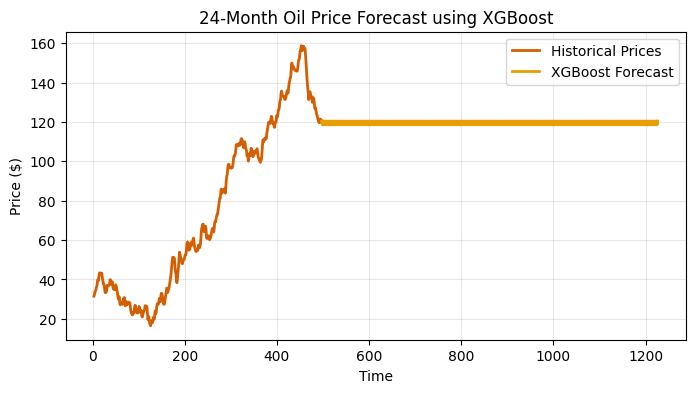

In [174]:
plt.figure(figsize=(8,4))

plt.plot(df['price_dollars'],
         label="Historical Prices",
         color='#D55E00',
         linewidth=2)

plt.plot(range(len(df), len(df)+future_days),
         future_predictions,
         label="XGBoost Forecast",
         color='#E69F00',
         linewidth=2)

plt.title("24-Month Oil Price Forecast using XGBoost")
plt.xlabel("Time")
plt.ylabel("Price ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#Implementing LSTM MODEL(optional model)

**Scaling Data**

In [176]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['price_dollars']])

**Create Sequences**

In [177]:
def create_sequences(data, seq_length=60):
    X, y = [], []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

**Building LSTM Model**

In [178]:
model_lstm = Sequential()

model_lstm.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1],1)))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(100))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X_train, y_train, epochs=10, batch_size=64)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1798
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0253
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0132
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0058
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0066
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0032
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0026
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0024
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0019
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021


In [179]:
#This is the code for perdictions
predictions = model_lstm.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [180]:
#RMSE
rmse_lstm = sqrt(mean_squared_error(y_test_actual, predictions))
print("LSTM RMSE:", rmse_lstm)


LSTM RMSE: 9.185999583552633


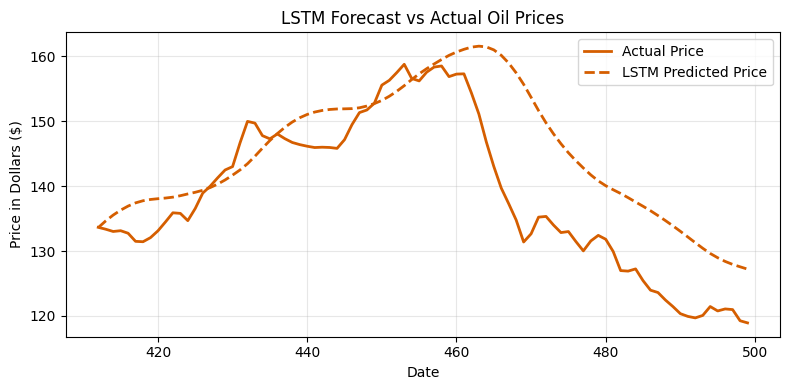

In [181]:
plt.figure(figsize=(8,4))

# This is Actual oil prices
plt.plot(df.index[-len(y_test_actual):],
         y_test_actual.flatten(),
         label="Actual Price",
         color='#D55E00',
         linewidth=2)

# This is the LSTM predicted prices
plt.plot(df.index[-len(predictions):],
         predictions.flatten(),
         label="LSTM Predicted Price",
         color='#D55E00',
         linewidth=2,
         linestyle='--')

plt.title("LSTM Forecast vs Actual Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price in Dollars ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

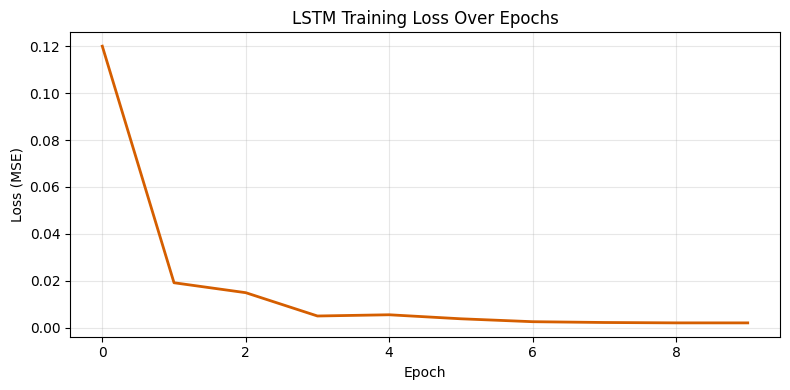

In [182]:
plt.figure(figsize=(8,4))

# Plotting training loss over epochs
plt.plot(model_lstm.history.history['loss'],
         color='#D55E00',
         linewidth=2)

plt.title("LSTM Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [183]:
comparison = pd.DataFrame({
    "Model": ["ARIMA","Prophet","LSTM"],
    "RMSE": [rmse, rmse_prophet, rmse_lstm]
})

print(comparison)

     Model       RMSE
0    ARIMA  18.529996
1  Prophet  13.122368
2     LSTM   9.186000


#Compariosn Plots

**RMSE Comparison Bar Chart**

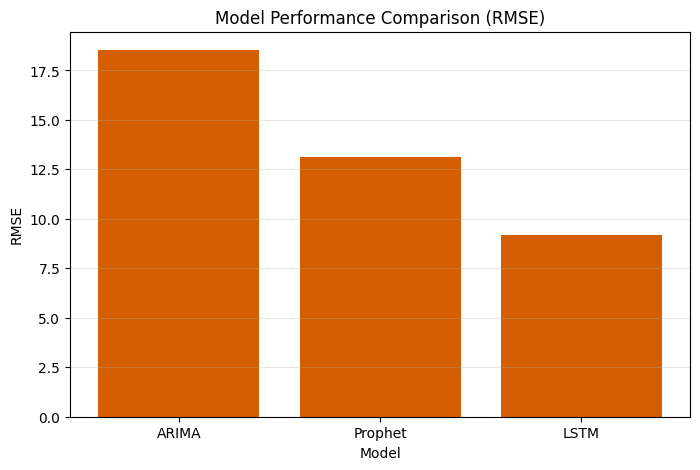

In [189]:
models = ['ARIMA', 'Prophet', 'LSTM']
rmse_values = [rmse, rmse_prophet, rmse_lstm]

plt.figure(figsize=(8,5))

plt.bar(models, rmse_values, color='#D55E00')

plt.title("Model Performance Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.grid(axis='y', alpha=0.3)

plt.show()

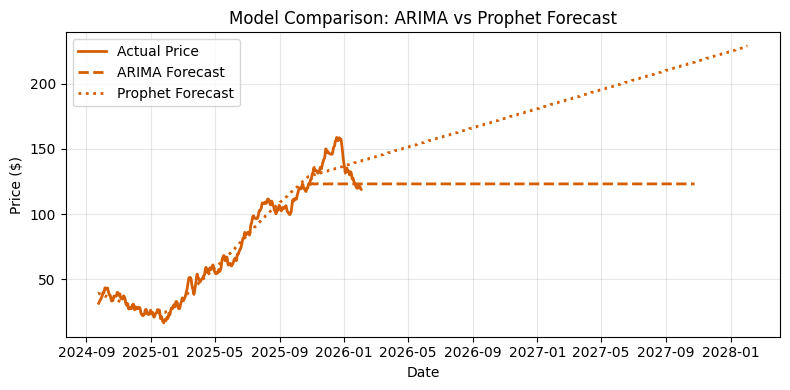

In [196]:
plt.figure(figsize=(8,4))

# Actual prices
plt.plot(df['date'], df['price_dollars'],
         label='Actual Price',
         color='#D55E00',
         linewidth=2)

# ARIMA forecast
plt.plot(mean_forecast.index, mean_forecast,
         label='ARIMA Forecast',
         color='#D55E00',
         linewidth=2,
         linestyle='--')

# Prophet forecast
plt.plot(forecast_prophet['ds'], forecast_prophet['yhat'],
         label='Prophet Forecast',
         color='#D55E00',
         linewidth=2,
         linestyle=':')

plt.title("Model Comparison: ARIMA vs Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [203]:
comparison_table = pd.DataFrame({
    "Model": ["ARIMA (3,1,3)", "Prophet"],
    "Type": ["Statistical Time-Series Model", "Additive Forecasting Model"],
    "RMSE": [rmse, rmse_prophet],
    "Forecast Behaviour": [
        "Stable forecast with widening confidence intervals",
        "Trend-following forecast with smoother behaviour"
    ]
})

comparison_table

,Model,Type,RMSE,Forecast Behaviour
0,"ARIMA (3,1,3)",Statistical Time-Series Model,18.529996,Stable forecast with widening confidence inter...
1,Prophet,Additive Forecasting Model,13.122368,Trend-following forecast with smoother behaviour
